# Customer Segmentation with K-Means — The Master Notebook

**Author:** Horia-Iulian State

**Companion material:**
* my presentation *An Introduction to K-Means* — `presentation/Presentation_beta3.pptx`
* my from-scratch implementation — `src/kmeans.py`
* the download script for every dataset used here — `data/get_data.py`

This notebook is the practical proof of the claims made in the presentation. There, I argued that
K-means is simple, fast and genuinely useful — but only if you choose K honestly, scale your
features, and can *name* the clusters you find. Here I test those claims on **three real customer
datasets** of increasing difficulty:

| Chapter | Dataset | Size | What it proves |
|---|---|---|---|
| 1 | Synthetic blobs | 500 points | My from-scratch K-means matches scikit-learn |
| 2 | Mall Customers | 200 customers | Choosing K with the elbow **and** the silhouette |
| 3 | Wholesale Customers (UCI) | 440 clients | Scaling decides everything |
| 4 | Online Retail (UCI) | 541,909 transactions | Feature engineering (RFM) turns raw logs into business segments |

The style follows my *Lessons Learned* notebook: one import cell for everything, short chapters,
and every chapter ends with its lesson in **bold**.

In [1]:
# One import cell for the whole notebook
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# compat shim: my local env pairs an old scikit-learn with a newer NumPy, which
# floods the output with `np.float is deprecated` warnings. Restoring the alias
# is a no-op on any modern stack.
np.float, np.int, np.bool = float, int, bool

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

sys.path.append('../src')
from kmeans import KMeansScratch          # my own implementation

SEED = 42
np.random.seed(SEED)

FIG_DIR = '../reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Chapter 1 — The algorithm, by hand

The flowchart on slide 6 of my presentation (*Fig. 1 — Initial Scenario Concept*) reads:

> Start → Choose Nr. of clusters → Randomly set centroids → Distance of each object to the
> centroids → Group on minimum distance → Recompute centroids → repeat until no object changes group.

`src/kmeans.py` is exactly that flowchart in ~40 lines of NumPy, using squared Euclidean distance
(the same choice discussed on the *"What type of distance should we use?"* slide). It also keeps the
best of `n_init` random restarts — the standard defence against one unlucky initialisation.

### 1.1 Does my implementation agree with scikit-learn?
If both are correct they should find the same partition on an easy problem. The
**adjusted Rand score** compares two clusterings while ignoring label order — 1.0 means identical
partitions. (Same metric I used to compare K-means, agglomerative and DBSCAN in my clustering
homework.)

agreement (adjusted Rand):  1.0
my inertia:                 1148.2
sklearn inertia:            1148.2


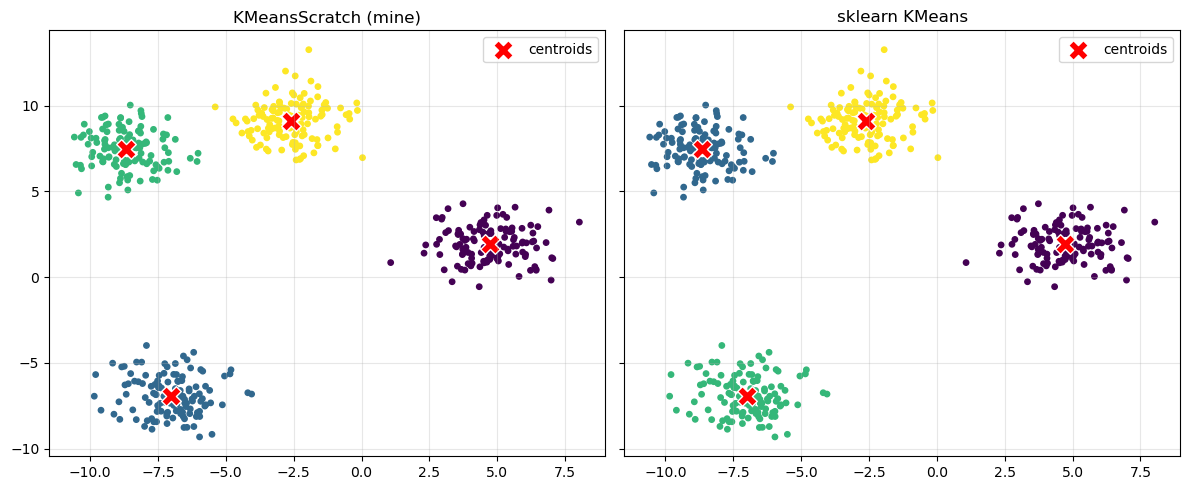

In [2]:
X_blobs, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.1, random_state=SEED)

mine = KMeansScratch(n_clusters=4, n_init=10, random_state=SEED).fit(X_blobs)
ref  = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X_blobs)

print('agreement (adjusted Rand): ', round(adjusted_rand_score(mine.labels_, ref.labels_), 4))
print('my inertia:                ', round(mine.inertia_, 1))
print('sklearn inertia:           ', round(ref.inertia_, 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, model, title in [(axes[0], mine, 'KMeansScratch (mine)'),
                         (axes[1], ref,  'sklearn KMeans')]:
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=model.labels_, cmap='viridis', s=15)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
               marker='X', s=200, c='red', edgecolor='white', label='centroids')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ch1_scratch_vs_sklearn.png', bbox_inches='tight')
plt.show()

Identical partitions, near-identical inertia. The tiny inertia gap is initialisation:
scikit-learn uses **k-means++** (spread the initial seeds out on purpose), mine picks seeds
uniformly at random — which is precisely why `n_init` restarts matter more for my version.

**Lesson: write the algorithm once by hand to understand it, then use the library forever.**

---
## Chapter 2 — Mall Customers: choosing K honestly

*(200 mall customers: age, annual income, spending score. The "hello world" of segmentation.)*

### 2.1 A first look

In [3]:
mall = pd.read_csv('../data/Mall_Customers.csv')
print(mall.shape)
mall.head()

(200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
mall.describe().round(1)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0,200.0
mean,100.5,38.8,60.6,50.2
std,57.9,14.0,26.3,25.8
min,1.0,18.0,15.0,1.0
25%,50.8,28.8,41.5,34.8
50%,100.5,36.0,61.5,50.0
75%,150.2,49.0,78.0,73.0
max,200.0,70.0,137.0,99.0


No missing values, sensible ranges. I segment on **Annual Income** vs **Spending Score** —
the two business-relevant axes (and both already on comparable scales, so no scaling drama yet;
Chapter 3 is where that bites).

### 2.2 Choosing K — elbow *and* silhouette
In the presentation I listed *"difficult to guess the correct K"* as a core weakness of K-means.
The honest workaround is to let two independent diagnostics vote, exactly as I did in my clustering
homework:

* **Elbow**: within-cluster sum of squares (inertia) always drops as K grows — look for the kink
  where adding a cluster stops paying for itself.
* **Silhouette**: for each point, (separation − cohesion) / max(both), averaged. Higher is better,
  and it *can* single out a maximum — which the elbow can't.

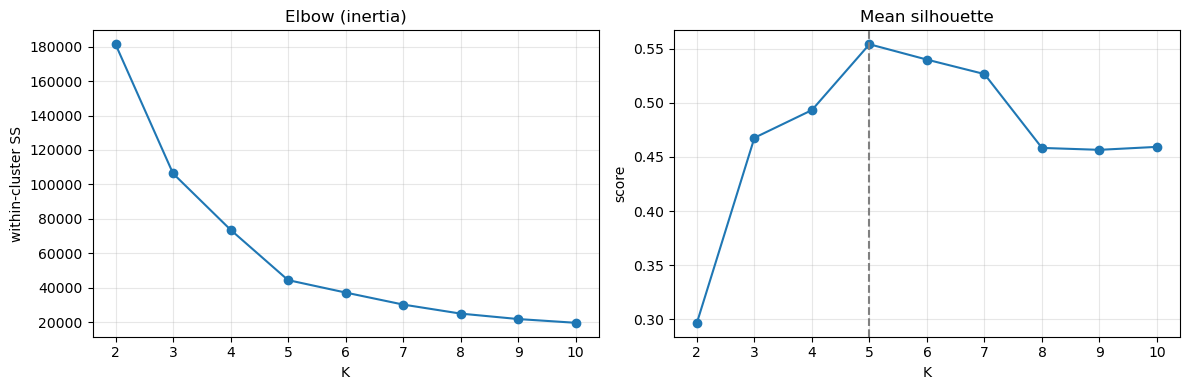

best K by silhouette: 5


In [5]:
X_mall = mall[['Annual Income (k$)', 'Spending Score (1-100)']].values

ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_mall)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_mall, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertia, 'o-')
axes[0].set(title='Elbow (inertia)', xlabel='K', ylabel='within-cluster SS')
axes[1].plot(list(ks), sil, 'o-')
axes[1].set(title='Mean silhouette', xlabel='K', ylabel='score')
axes[1].axvline(int(np.array(list(ks))[np.argmax(sil)]), ls='--', c='grey')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ch2_choosing_k.png', bbox_inches='tight')
plt.show()

print('best K by silhouette:', int(np.array(list(ks))[np.argmax(sil)]))

Both diagnostics agree: the elbow kinks at **K = 5** and the silhouette peaks there too.
When they agree, trust them; when they don't, prefer the silhouette plus business judgement.

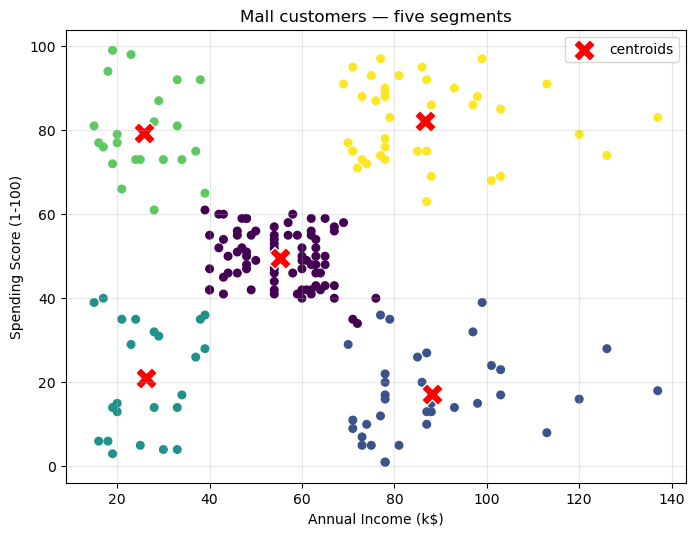

In [6]:
km5 = KMeans(n_clusters=5, n_init=10, random_state=SEED).fit(X_mall)
mall['segment'] = km5.labels_

plt.figure(figsize=(8, 6))
plt.scatter(X_mall[:, 0], X_mall[:, 1], c=km5.labels_, cmap='viridis', s=30)
plt.scatter(km5.cluster_centers_[:, 0], km5.cluster_centers_[:, 1],
            marker='X', s=250, c='red', edgecolor='white', label='centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Mall customers — five segments')
plt.legend()
plt.savefig(f'{FIG_DIR}/ch2_mall_segments.png', bbox_inches='tight')
plt.show()

### 2.3 Naming the segments
A cluster number is useless to a marketing team; a *persona* is not. Reading the centroids:

In [7]:
profile = (mall.groupby('segment')
               .agg(customers=('CustomerID', 'count'),
                    mean_age=('Age', 'mean'),
                    mean_income=('Annual Income (k$)', 'mean'),
                    mean_spending=('Spending Score (1-100)', 'mean'))
               .round(1)
               .sort_values('mean_income'))

# name by position in the income x spending plane
def persona(row):
    inc_high = row['mean_income'] >= mall['Annual Income (k$)'].mean()
    spend_high = row['mean_spending'] >= mall['Spending Score (1-100)'].mean()
    return {(True, True):   'Target: affluent big spenders',
            (True, False):  'Careful rich (untapped)',
            (False, True):  'Carefree spenders (watch credit risk)',
            (False, False): 'Budget-conscious'}[(inc_high, spend_high)]

profile['persona'] = profile.apply(persona, axis=1)
# the middle cluster sits near both means -> it is simply the mainstream
mid = (profile['mean_income'] - mall['Annual Income (k$)'].mean()).abs().idxmin()
profile.loc[mid, 'persona'] = 'Mainstream middle'
profile

,customers,mean_age,mean_income,mean_spending,persona
segment,,,,,
3,22,25.3,25.7,79.4,Carefree spenders (watch credit risk)
2,23,45.2,26.3,20.9,Budget-conscious
0,81,42.7,55.3,49.5,Mainstream middle
4,39,32.7,86.5,82.1,Target: affluent big spenders
1,35,41.1,88.2,17.1,Careful rich (untapped)


Five segments, five different marketing actions — the affluent big spenders get loyalty
perks, the "careful rich" are the growth opportunity, the carefree spenders need payment-risk
monitoring.

**Lesson: a cluster is only useful once you can name it and attach an action to it.**

---
## Chapter 3 — Wholesale Customers: scaling decides everything

*(UCI dataset: annual spend of 440 wholesale clients of a Portuguese distributor across six product
categories, plus their sales Channel — horeca vs retail — which I hold out as a reality check.)*

### 3.1 A first look

In [8]:
ws = pd.read_csv('../data/wholesale_customers.csv')
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
print(ws.shape)
ws[spend_cols].describe().round(0)

(440, 8)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.0,5796.0,7951.0,3072.0,2881.0,1525.0
std,12647.0,7380.0,9503.0,4855.0,4768.0,2820.0
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3128.0,1533.0,2153.0,742.0,257.0,408.0
50%,8504.0,3627.0,4756.0,1526.0,816.0,966.0
75%,16934.0,7190.0,10656.0,3554.0,3922.0,1820.0
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


### 3.2 The scaling trap
Look at the variances. `Fresh` spans 3 to 112,151 — its variance dwarfs every other column.
K-means only sees squared Euclidean distance, so on raw data the algorithm effectively clusters on
`Fresh` alone. Watch:

In [9]:
print('variance per feature (raw):')
print(ws[spend_cols].var().round(0).astype('int64').sort_values(ascending=False))

raw_km = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(ws[spend_cols].values)
centroids_raw = pd.DataFrame(raw_km.cluster_centers_, columns=spend_cols).round(0)
print('\ncluster sizes (raw):', np.bincount(raw_km.labels_))
print('\ncentroids on raw data - they differ almost only in Fresh:')
centroids_raw

variance per feature (raw):
Fresh               159954927
Grocery              90310104
Milk                 54469967
Frozen               23567853
Detergents_Paper     22732436
Delicassen            7952997
dtype: int64

cluster sizes (raw): [ 60 330  50]

centroids on raw data - they differ almost only in Fresh:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,35941.0,6044.0,6289.0,6714.0,1040.0,3049.0
1,8253.0,3825.0,5280.0,2573.0,1773.0,1137.0
2,8000.0,18511.0,27574.0,1997.0,12407.0,2252.0


One giant cluster and two small ones, and the centroids differ by an order of magnitude in
`Fresh` while barely moving elsewhere. This "clustering" is just a binning of one column.

The fix is two standard moves:
1. **log-transform** — spend data is heavily right-skewed (a few huge accounts), `log1p` tames it;
2. **standardise** — so every category contributes on equal terms.

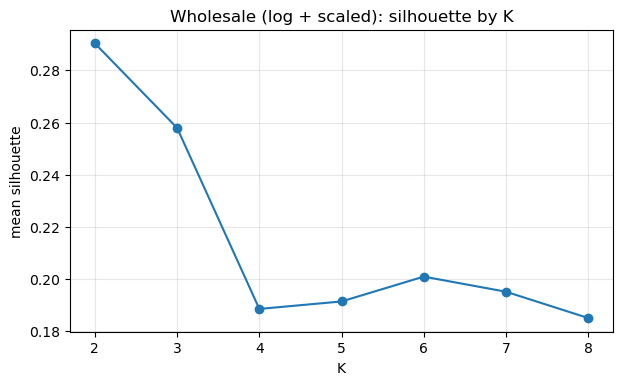

best K by silhouette: 2


In [10]:
X_ws = StandardScaler().fit_transform(np.log1p(ws[spend_cols].values))

ks = range(2, 9)
sil = [silhouette_score(X_ws, KMeans(n_clusters=k, n_init=10, random_state=SEED)
                        .fit_predict(X_ws)) for k in ks]
plt.figure(figsize=(7, 4))
plt.plot(list(ks), sil, 'o-')
plt.xlabel('K'); plt.ylabel('mean silhouette')
plt.title('Wholesale (log + scaled): silhouette by K')
plt.show()
print('best K by silhouette:', int(np.array(list(ks))[np.argmax(sil)]))

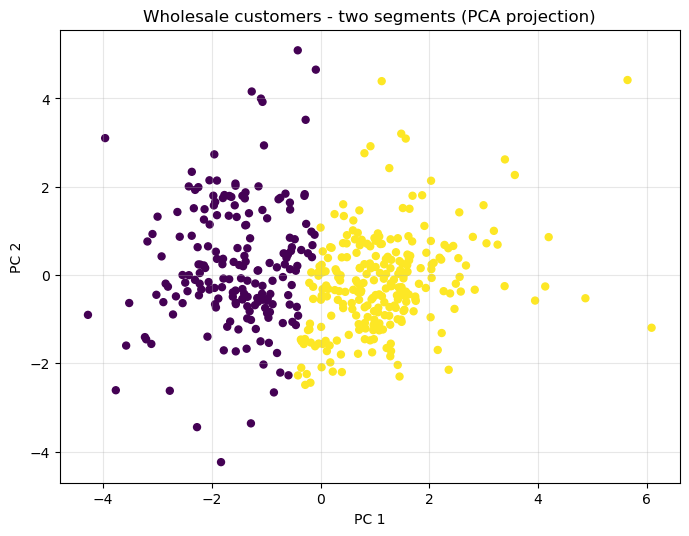

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,clients
segment,,,,,,,
0,5406,7690,11527,1062,4495,1388,188
1,10348,1871,2406,2225,328,750,252


In [11]:
km_ws = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_ws)
ws['segment'] = km_ws.labels_

# 2-D view via PCA (my homework used t-SNE for the same job; PCA is enough at 440 rows
# and has the bonus of being deterministic)
pts = PCA(n_components=2, random_state=SEED).fit_transform(X_ws)
plt.figure(figsize=(8, 6))
plt.scatter(pts[:, 0], pts[:, 1], c=km_ws.labels_, cmap='viridis', s=25)
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.title('Wholesale customers - two segments (PCA projection)')
plt.savefig(f'{FIG_DIR}/ch3_wholesale_pca.png', bbox_inches='tight')
plt.show()

profile_ws = ws.groupby('segment')[spend_cols].median().round(0).astype('int64')
profile_ws['clients'] = ws.groupby('segment').size()
profile_ws

### 3.3 The reality check
The dataset ships with the true sales **Channel** (1 = horeca: hotels/restaurants/cafés,
2 = retail), which I deliberately did not show to the algorithm. If the segments are real,
they should line up with it:

In [12]:
ari = adjusted_rand_score(ws['Channel'], ws['segment'])
print('adjusted Rand vs. held-out Channel:', round(ari, 3))
pd.crosstab(ws['Channel'].map({1: 'horeca', 2: 'retail'}),
            ws['segment'], rownames=['true channel'], colnames=['found segment'])

adjusted Rand vs. held-out Channel: 0.514


found segment,0,1
true channel,,
horeca,54,244
retail,134,8


The unsupervised segments recover the actual business channel structure: one segment is the
fresh/frozen-heavy **horeca** buyers, the other the grocery/detergents-heavy **retail** buyers —
without ever seeing the label. On raw, unscaled data this signal was invisible.

**Lesson: K-means sees only distance. Log-transform skewed money columns and standardise before
clustering, or one big-variance feature silently makes the decision for you.**

---
## Chapter 4 — Online Retail: from 541,909 raw transactions to segments a CRM can use

*(UCI dataset: every transaction of a UK online gift retailer, Dec 2010 – Dec 2011. This is the
realistic case — no ready-made customer table exists. I have to build one.)*

### 4.1 Cleaning: know what you throw away

In [13]:
retail = pd.read_csv('../data/online_retail.csv.gz', parse_dates=['InvoiceDate'])
n0 = len(retail)
print('raw transactions:      ', n0)

retail = retail.dropna(subset=['CustomerID'])                 # guest checkouts - no one to segment
n1 = len(retail); print('with a CustomerID:     ', n1, f'(dropped {n0 - n1})')

retail = retail[~retail['InvoiceNo'].astype(str).str.startswith('C')]   # cancellations
n2 = len(retail); print('without cancellations: ', n2, f'(dropped {n1 - n2})')

retail = retail[(retail['Quantity'] > 0) & (retail['UnitPrice'] > 0)]   # adjustments, freebies
n3 = len(retail); print('positive qty & price:  ', n3, f'(dropped {n2 - n3})')

retail['Revenue'] = retail['Quantity'] * retail['UnitPrice']
print('customers:             ', retail['CustomerID'].nunique())

raw transactions:       541909
with a CustomerID:      406829 (dropped 135080)
without cancellations:  397924 (dropped 8905)
positive qty & price:   397884 (dropped 40)
customers:              4338


A quarter of the rows had no `CustomerID` — those are guest checkouts, and silently keeping
them would have invented a giant phantom customer. Every drop is printed and justified; a cleaning
step you can't explain is a bug you haven't found yet.

### 4.2 Feature engineering — RFM
K-means needs one row per *customer*, not per transaction. The classic marketing summary is
**RFM**:

* **Recency** — days since last purchase (lower = better)
* **Frequency** — number of distinct orders
* **Monetary** — total revenue

Three numbers, decades of CRM practice behind them, and each one directly actionable.

In [14]:
snapshot = retail['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = (retail.groupby('CustomerID')
             .agg(Recency=('InvoiceDate', lambda d: (snapshot - d.max()).days),
                  Frequency=('InvoiceNo', 'nunique'),
                  Monetary=('Revenue', 'sum')))
print(rfm.shape)
rfm.describe().round(1)

(4338, 3)


,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0
mean,92.5,4.3,2054.3
std,100.0,7.7,8989.2
min,1.0,1.0,3.8
25%,18.0,1.0,307.4
50%,51.0,2.0,674.5
75%,142.0,5.0,1661.7
max,374.0,209.0,280206.0


### 4.3 Transform, then choose K
Same trap as Chapter 3, worse: `Monetary` runs from a few pounds to hundreds of thousands.
So: `log1p`, standardise, then let the silhouette vote.

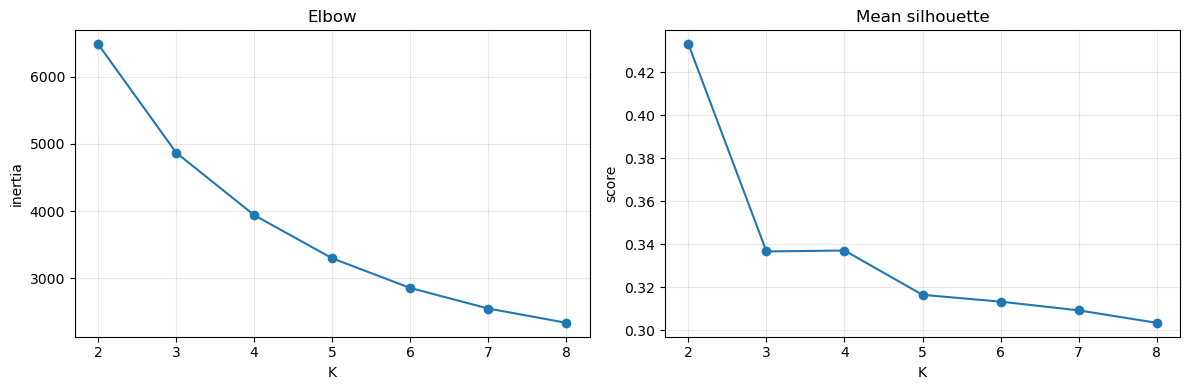

silhouette by K: {2: 0.433, 3: 0.337, 4: 0.337, 5: 0.316, 6: 0.313, 7: 0.309, 8: 0.303}


In [15]:
X_rfm = StandardScaler().fit_transform(np.log1p(rfm.values))

ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_rfm)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_rfm, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertia, 'o-')
axes[0].set(title='Elbow', xlabel='K', ylabel='inertia')
axes[1].plot(list(ks), sil, 'o-')
axes[1].set(title='Mean silhouette', xlabel='K', ylabel='score')
plt.tight_layout()
plt.show()
print('silhouette by K:', dict(zip(ks, np.round(sil, 3))))

The silhouette favours small K (2–3) — typical for RFM, where customers form a continuum
rather than islands. I choose **K = 4** deliberately: silhouette barely drops from 3 to 4, and four
groups map onto the standard CRM playbook (champions / loyal / promising / at-risk). This is the
presentation's *"user provides K"* weakness turned into a feature — the business gets a say.

In [16]:
km_rfm = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X_rfm)
rfm['segment'] = km_rfm.labels_

seg = (rfm.groupby('segment')
          .agg(customers=('Recency', 'size'),
               median_recency_days=('Recency', 'median'),
               median_orders=('Frequency', 'median'),
               median_revenue=('Monetary', 'median'),
               total_revenue=('Monetary', 'sum'))
          .sort_values('total_revenue', ascending=False))
seg['revenue_share_%'] = (100 * seg['total_revenue'] / seg['total_revenue'].sum()).round(1)

# name segments from their own numbers: the two highest-value clusters by revenue,
# then the remaining two split by recency (recent = promising, long-gone = at-risk)
tail = seg.iloc[2:].sort_values('median_recency_days')
seg = seg.loc[list(seg.index[:2]) + list(tail.index)]
seg['persona'] = ['Champions', 'Loyal regulars', 'Promising / new', 'At-risk / hibernating']
seg.round(1)

,customers,median_recency_days,median_orders,median_revenue,total_revenue,revenue_share_%,persona
segment,,,,,,,
2,712,8,10,3739.2,5768944.2,64.7,Champions
3,1172,55,4,1352.4,2121644.1,23.8,Loyal regulars
0,837,17,2,470.8,460371.4,5.2,Promising / new
1,1617,176,1,298.9,560448.3,6.3,At-risk / hibernating


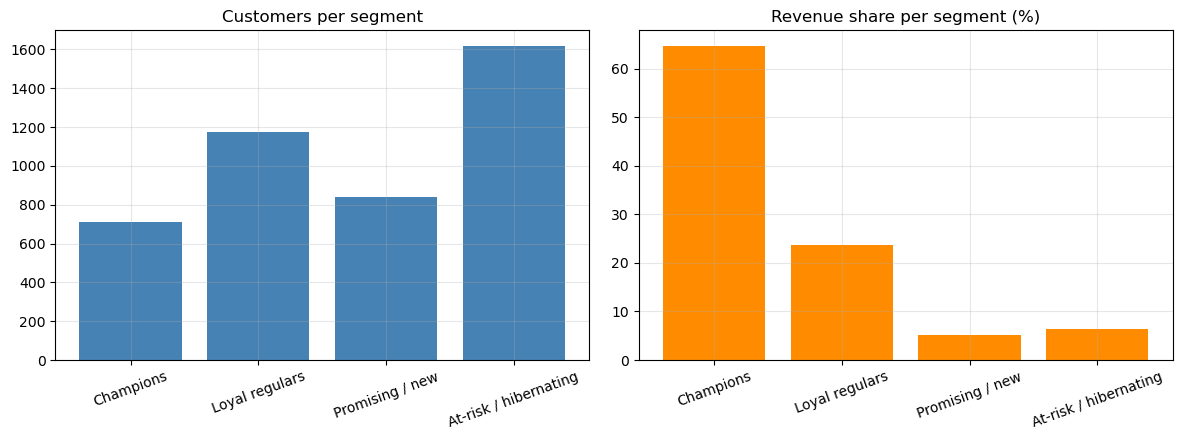

In [17]:
order = seg.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(seg['persona'], seg['customers'], color='steelblue')
axes[0].set_title('Customers per segment')
axes[1].bar(seg['persona'], seg['revenue_share_%'], color='darkorange')
axes[1].set_title('Revenue share per segment (%)')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ch4_rfm_segments.png', bbox_inches='tight')
plt.show()

### 4.4 What the business does with this
The point of the whole exercise, in one table: a small share of customers carries most of the
revenue, and each segment gets its own play —

| Segment | Play |
|---|---|
| **Champions** | protect: early access, loyalty tier, never spam them |
| **Loyal regulars** | grow: cross-sell, subscription offers |
| **Promising / new** | convert: onboarding series, second-purchase voucher |
| **At-risk / hibernating** | win back *selectively*: reactivation offer only where past value justifies it |

**Lesson: on real data, most of the value is in the cleaning and the feature engineering — the
clustering itself is three lines.**

---
## Chapter 5 — Lessons learned

1. **Write it by hand once, then use the library.** My 40-line NumPy K-means matches scikit-learn
   exactly (Chapter 1); scikit-learn adds k-means++ initialisation and years of hardening.
2. **Never guess K alone.** Elbow + silhouette together, plus business judgement when they are
   indifferent (Chapters 2 and 4).
3. **Scale or lose.** Unscaled money columns reduce K-means to single-feature binning
   (Chapter 3). `log1p` + `StandardScaler` is the default move for spend data.
4. **Validate against something the model never saw.** The wholesale segments recovered the true
   sales channel (ARI, Chapter 3) — that is what separates "the algorithm converged" from
   "the segments are real".
5. **A segment needs a name and an action.** Personas in Chapter 2, the CRM playbook in
   Chapter 4. If you can't say what you'd *do* with a cluster, you don't have a segmentation —
   you have a scatter plot with colours.

### Known limits & where I'd go next
Straight from the *Weaknesses* slide of the presentation, now demonstrated first-hand: K-means
assumes roughly spherical, similar-sized clusters, is sensitive to outliers, and needs K up front.
On the RFM continuum a **Gaussian mixture** (soft memberships) or **DBSCAN** (no K, finds outliers)
would be the natural next experiments — both of which I benchmarked against K-means in my
clustering homework using the adjusted Rand score.